<a href="https://colab.research.google.com/github/bloodrepaer/nifty-vix-kalman/blob/main/strategy_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VIX Kalman Regime Engine — Strategy B (Conviction + Stability Filter)
**Based on Sarthak's advice**: frequency of trades + conviction-based sizing

**Changes vs Strategy A:**
- **Stability filter**: only trade when regime has been stable for 3+ consecutive days — avoids whipsaw on fresh regime flips
- **Conviction scoring**: position scaled by how deep into the regime the Z-score is — borderline calm gets less size than deep calm
- **Result**: fewer trades, higher conviction per trade, lower unnecessary exposure

In [1]:
pip install pykalman

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 12.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from pykalman import KalmanFilter
from scipy.stats import percentileofscore
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

NIFTY_CSV          = 'Nifty50_data.csv'
INITIAL_CAPITAL    = 100_000
RISK_FREE_RATE     = 0.065
VOL_TARGET         = 0.20
MAX_LEVERAGE       = 3.0
SLIPPAGE_BPS       = 8
DD_CIRCUIT_BREAKER = 0.10
VIX_ZSCORE_WINDOW  = 126
VIX_PCT_WINDOW     = 252
VIX_SPIKE_THRESH   = 0.20
STABILITY_DAYS     = 3

REGIME_SCALARS = {
    'Extreme Panic': 0.65,
    'Panic':         0.80,
    'Fear (live)':   0.75,
    'Fear (buy)':    1.20,
    'Recovery':      2.00,
    'Calm':          1.80,
    'Neutral':       1.20,
}

# Boundary z-scores — used to compute conviction depth
REGIME_BOUNDARIES = {
    'Extreme Panic': 3.0,
    'Panic':         2.0,
    'Fear (live)':   1.2,
    'Fear (buy)':    1.2,
    'Recovery':      0.0,
    'Calm':         -0.3,
    'Neutral':       0.0,
}

C = dict(green='#00ff88', blue='#00bfff', red='#ff4466',
         gold='#ffdd00', grid='#2a2a2a', text='#cccccc', bg='#0d0d0d', panel='#141414')
print('Config loaded.')

Config loaded.


In [3]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(NIFTY_CSV)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_convert('Asia/Kolkata')
df = df.set_index('datetime').sort_index()
df = df.drop(columns=[c for c in ['volume','oi'] if c in df.columns])
df = df.between_time('09:15','15:30')

daily = df.resample('D').agg({'open':'first','high':'max','low':'min','close':'last'}).dropna()
daily.index = daily.index.tz_localize(None)

start_str = str(daily.index[0].date())
end_str   = str((daily.index[-1] + pd.Timedelta(days=1)).date())
vix_dl    = yf.download('^INDIAVIX', start=start_str, end=end_str, progress=False, auto_adjust=True)
vix_raw   = vix_dl['Close']['^INDIAVIX'] if isinstance(vix_dl.columns, pd.MultiIndex) else vix_dl['Close']
vix_raw.index = pd.to_datetime(vix_raw.index).tz_localize(None)
vix_raw.name  = 'VIX'
print(f'Daily bars: {len(daily)} | Range: {daily.index[0].date()} to {daily.index[-1].date()}')

Daily bars: 574 | Range: 2017-01-02 to 2019-05-02


In [4]:
# ── Kalman filter on VIX ──────────────────────────────────────────────────────
kf = KalmanFilter(
    transition_matrices=np.array([[1,1],[0,1]]),
    observation_matrices=np.array([[1,0]]),
    initial_state_mean=[float(vix_raw.iloc[0]), 0.0],
    initial_state_covariance=np.eye(2),
    transition_covariance=np.eye(2)*1e-4,
    observation_covariance=np.array([[0.8]])
)
states, _ = kf.filter(vix_raw.values)

vix = pd.DataFrame({
    'VIX':      vix_raw.values,
    'KF_Level': states[:,0],
    'KF_Vel':   states[:,1]
}, index=vix_raw.index)

rm = vix['KF_Level'].rolling(VIX_ZSCORE_WINDOW, min_periods=21).mean()
rs = vix['KF_Level'].rolling(VIX_ZSCORE_WINDOW, min_periods=21).std().replace(0, np.nan)
vix['VIX_Z'] = (vix['KF_Level'] - rm) / rs

def rpct(x):
    return percentileofscore(x[:-1], x.iloc[-1]) / 100.0
vix['VIX_Pct'] = vix['VIX'].rolling(VIX_PCT_WINDOW, min_periods=63).apply(rpct, raw=False)

vel_std      = vix['KF_Vel'].rolling(42, min_periods=14).std().replace(0, np.nan)
vix['VelZ']  = vix['KF_Vel'] / vel_std
vix['Spike'] = (vix['VIX'].pct_change() > VIX_SPIKE_THRESH).astype(int).rolling(3, min_periods=1).max()
print('Kalman filter applied.')

Kalman filter applied.


In [5]:
# ── Regime assignment ─────────────────────────────────────────────────────────
vz    = vix['VIX_Z'].fillna(0)
velz  = vix['VelZ'].fillna(0)
pct   = vix['VIX_Pct'].fillna(0.5)
spike = vix['Spike']

is_ep   = (vz > 3.0)
is_p    = (~is_ep) & ((vz > 2.0) | (spike > 0))
is_fl   = (~is_ep) & (~is_p) & (vz > 1.2) & (velz > 0.5)
is_fb   = (~is_ep) & (~is_p) & (vz > 1.2) & (velz <= 0.5)
is_rec  = (~is_ep) & (~is_p) & (~is_fl) & (~is_fb) & (velz < -1.0) & (pct > 0.45)
is_calm = (~is_ep) & (~is_p) & (~is_fl) & (~is_fb) & (~is_rec) & (vz < -0.3)

regime = np.where(is_ep,   'Extreme Panic',
          np.where(is_p,   'Panic',
          np.where(is_fl,  'Fear (live)',
          np.where(is_fb,  'Fear (buy)',
          np.where(is_rec, 'Recovery',
          np.where(is_calm,'Calm', 'Neutral'))))))

vix['Regime'] = regime
vix['Scalar'] = pd.Series(regime, index=vix.index).map(REGIME_SCALARS)

# ── Stability filter ─────────────────────────────────────────────────────────
# Only trade when regime has been unchanged for STABILITY_DAYS consecutive days
regime_s       = pd.Series(regime, index=vix.index)
regime_changed = (regime_s != regime_s.shift(1)).astype(int)
stable_days    = regime_changed.groupby((regime_changed == 1).cumsum()).cumcount()
vix['StableDays'] = stable_days
vix['IsStable']   = (stable_days >= STABILITY_DAYS).astype(int)

# ── Conviction score ─────────────────────────────────────────────────────────
# How deep into the regime is the Z-score? Normalised 0.0 to 1.0.
# Deep calm (Z=-1.8) = conviction 1.0, borderline calm (Z=-0.31) = conviction ~0.01
def compute_conviction(row):
    r   = row['Regime']
    z   = row['VIX_Z']
    bnd = REGIME_BOUNDARIES.get(r, 0.0)
    if r == 'Calm':
        return min(1.0, max(0, bnd - z) / 1.5)
    elif r in ['Extreme Panic','Panic','Fear (live)','Fear (buy)']:
        return min(1.0, max(0, z - bnd) / 1.5)
    elif r == 'Recovery':
        return min(1.0, max(0, -row['VelZ'] - 1.0) / 2.0)
    else:
        return 0.7

vix['Conviction'] = vix.apply(compute_conviction, axis=1)

total = len(regime)
print(f'Regime distribution ({total} days):')
for r in ['Extreme Panic','Panic','Fear (live)','Fear (buy)','Recovery','Calm','Neutral']:
    n      = (regime == r).sum()
    stable = vix[vix['Regime']==r]['IsStable'].mean() * 100
    print(f'  {r:<16}: {n:>4} days ({n/total*100:.1f}%)  stable {stable:.0f}%')
print(f'\nConviction: mean {vix["Conviction"].mean():.2f}  |  Stable days: {vix["IsStable"].sum()} / {total} ({vix["IsStable"].mean()*100:.1f}%)')

Regime distribution (574 days):
  Extreme Panic   :   23 days (4.0%)  stable 74%
  Panic           :   53 days (9.2%)  stable 55%
  Fear (live)     :   31 days (5.4%)  stable 42%
  Fear (buy)      :   26 days (4.5%)  stable 54%
  Recovery        :   67 days (11.7%)  stable 69%
  Calm            :  207 days (36.1%)  stable 86%
  Neutral         :  167 days (29.1%)  stable 80%

Conviction: mean 0.47  |  Stable days: 431 / 574 (75.1%)


In [6]:
# ── Backtest ──────────────────────────────────────────────────────────────────
ma5      = daily['close'].rolling(5).mean()
trend_ok = (daily['close'] > ma5).rename('TrendOK')

data = pd.concat([
    daily['close'].rename('NIFTY'),
    vix[['VIX_Z','Regime','Scalar','Conviction','IsStable']],
    trend_ok
], axis=1).ffill().dropna()
ret = data['NIFTY'].pct_change().fillna(0)

# Base scalar from regime
data['Scalar_use'] = data['Regime'].map(REGIME_SCALARS)

# Trend filter
data['Scalar_use'] = np.where(data['TrendOK'], data['Scalar_use'], data['Scalar_use'].clip(0, 1.0))

# Conviction scaling — floor at 0.4 so we never go fully flat from conviction alone
conviction = data['Conviction'].clip(0.4, 1.0)
data['Scalar_use'] = data['Scalar_use'] * conviction

# Stability filter — zero out position when regime just flipped
data['Scalar_use'] = np.where(data['IsStable'] == 1, data['Scalar_use'], 0.0)

# Vol-targeted position size
ewma_vol   = ret.ewm(span=21).std() * np.sqrt(252)
vol_scalar = (VOL_TARGET / ewma_vol.replace(0, np.nan)).clip(0.3, MAX_LEVERAGE)
raw_pos    = (data['Scalar_use'] * vol_scalar).clip(0, MAX_LEVERAGE).ewm(span=2).mean()

# Circuit breaker with gradual VIX-gated recovery
pos_arr   = raw_pos.values.copy()
ret_arr   = ret.values
vz_arr    = data['VIX_Z'].fillna(0).values
equity    = np.zeros(len(pos_arr))
equity[0] = INITIAL_CAPITAL
final_pos = np.zeros(len(pos_arr))
brake     = 1.0

for i in range(1, len(pos_arr)):
    final_pos[i] = pos_arr[i] * brake
    slip         = abs(final_pos[i] - final_pos[i-1]) * (SLIPPAGE_BPS / 10_000)
    equity[i]    = equity[i-1] * (1 + final_pos[i] * ret_arr[i] - slip)
    if i >= 20:
        peak_20 = np.max(equity[max(0,i-20):i+1])
        dd_20   = (equity[i] - peak_20) / peak_20
        if dd_20 < -DD_CIRCUIT_BREAKER:
            brake = 0.25
        elif brake < 1.0 and vz_arr[i] < 1.0:
            brake = 0.50 if brake == 0.25 else 1.00

strat_eq  = pd.Series(equity, index=data.index)
strat_ret = pd.Series(final_pos, index=data.index) * ret - \
            pd.Series(final_pos, index=data.index).diff().abs().fillna(0) * (SLIPPAGE_BPS/10_000)
bench_eq  = INITIAL_CAPITAL * (1 + ret).cumprod()

pos_changes = (pd.Series(final_pos).diff().abs() > 0.01).sum()
print(f'Strategy equity : Rs{strat_eq.iloc[-1]:,.0f}')
print(f'Benchmark equity: Rs{bench_eq.iloc[-1]:,.0f}')
print(f'Position changes: {pos_changes} (vs ~{len(data)} daily rebalances in Strategy A)')

Strategy equity : Rs176,642
Benchmark equity: Rs137,567
Position changes: 492 (vs ~556 daily rebalances in Strategy A)


In [7]:
# ── Metrics ───────────────────────────────────────────────────────────────────
def compute_metrics(r, name):
    r   = r[r != 0].dropna()
    ann = r.mean() * 252
    vol = r.std()  * np.sqrt(252)
    sh  = (ann - RISK_FREE_RATE) / vol if vol else 0
    eq  = INITIAL_CAPITAL * (1 + r).cumprod()
    pk  = eq.cummax()
    dd  = (eq - pk) / pk
    mdd = dd.min()
    cal = ann / abs(mdd) if mdd else 0
    dn  = r[r < 0]
    srt = (ann - RISK_FREE_RATE) / (dn.std() * np.sqrt(252)) if len(dn) else 0
    wr  = (r > 0).mean()
    pf  = r[r>0].sum() / abs(r[r<0].sum()) if len(r[r<0]) else np.inf
    in_dd = (dd < -0.01).astype(int)
    grp   = (in_dd != in_dd.shift()).cumsum()
    mdd_d = int(in_dd.groupby(grp).sum().max()) if len(in_dd) else 0
    print(f'\n{"="*50}\n  {name}\n{"="*50}')
    for label, val, fmt in [
        ('Ann. Return',     ann*100, '{:>10.1f}%'),
        ('Ann. Volatility', vol*100, '{:>10.1f}%'),
        ('Sharpe',          sh,      '{:>10.2f}x'),
        ('Sortino',         srt,     '{:>10.2f}x'),
        ('Max Drawdown',    mdd*100, '{:>10.1f}%'),
        ('Calmar',          cal,     '{:>10.2f}x'),
        ('Win Rate',        wr*100,  '{:>10.1f}%'),
        ('Profit Factor',   pf,      '{:>10.2f}x'),
        ('Max DD Duration', mdd_d,   '{:>10d}d'),
    ]:
        print(f'  {label:<22} {fmt.format(val)}')
    print(f'{"="*50}')
    return {'ann':ann,'vol':vol,'sharpe':sh,'mdd':mdd,'calmar':cal,
            'sortino':srt,'wr':wr,'pf':pf,'mdd_days':mdd_d}, dd

strat_m, strat_dd = compute_metrics(strat_ret, 'Strategy B — Conviction + Stability')
bench_m, bench_dd = compute_metrics(ret,        'NIFTY50 Buy & Hold')


  Strategy B — Conviction + Stability
  Ann. Return                  26.9%
  Ann. Volatility              12.0%
  Sharpe                       1.71x
  Sortino                      2.81x
  Max Drawdown                 -6.7%
  Calmar                       4.02x
  Win Rate                     51.9%
  Profit Factor                1.51x
  Max DD Duration               125d

  NIFTY50 Buy & Hold
  Ann. Return                  15.2%
  Ann. Volatility              11.2%
  Sharpe                       0.77x
  Sortino                      1.13x
  Max Drawdown                -14.7%
  Calmar                       1.03x
  Win Rate                     55.5%
  Profit Factor                1.25x
  Max DD Duration               140d


In [8]:
# ── Annual returns ────────────────────────────────────────────────────────────
ann_s = strat_ret.resample('YE').apply(lambda x: (1+x).prod()-1) * 100
ann_b = ret.resample('YE').apply(lambda x: (1+x).prod()-1) * 100
ann   = pd.DataFrame({'Strategy B %': ann_s.round(1), 'Benchmark %': ann_b.round(1)})
ann.index      = ann.index.year
ann['Alpha %'] = (ann['Strategy B %'] - ann['Benchmark %']).round(1)
ann['Beat']    = ann['Alpha %'].apply(lambda x: 'YES' if x > 0 else 'NO')
print(ann.to_string())

      Strategy B %  Benchmark %  Alpha % Beat
2017          30.3         23.0      7.3  YES
2018          28.2          3.2     25.0  YES
2019           5.8          8.4     -2.6   NO


Dashboard saved to strategy_b_dashboard.png


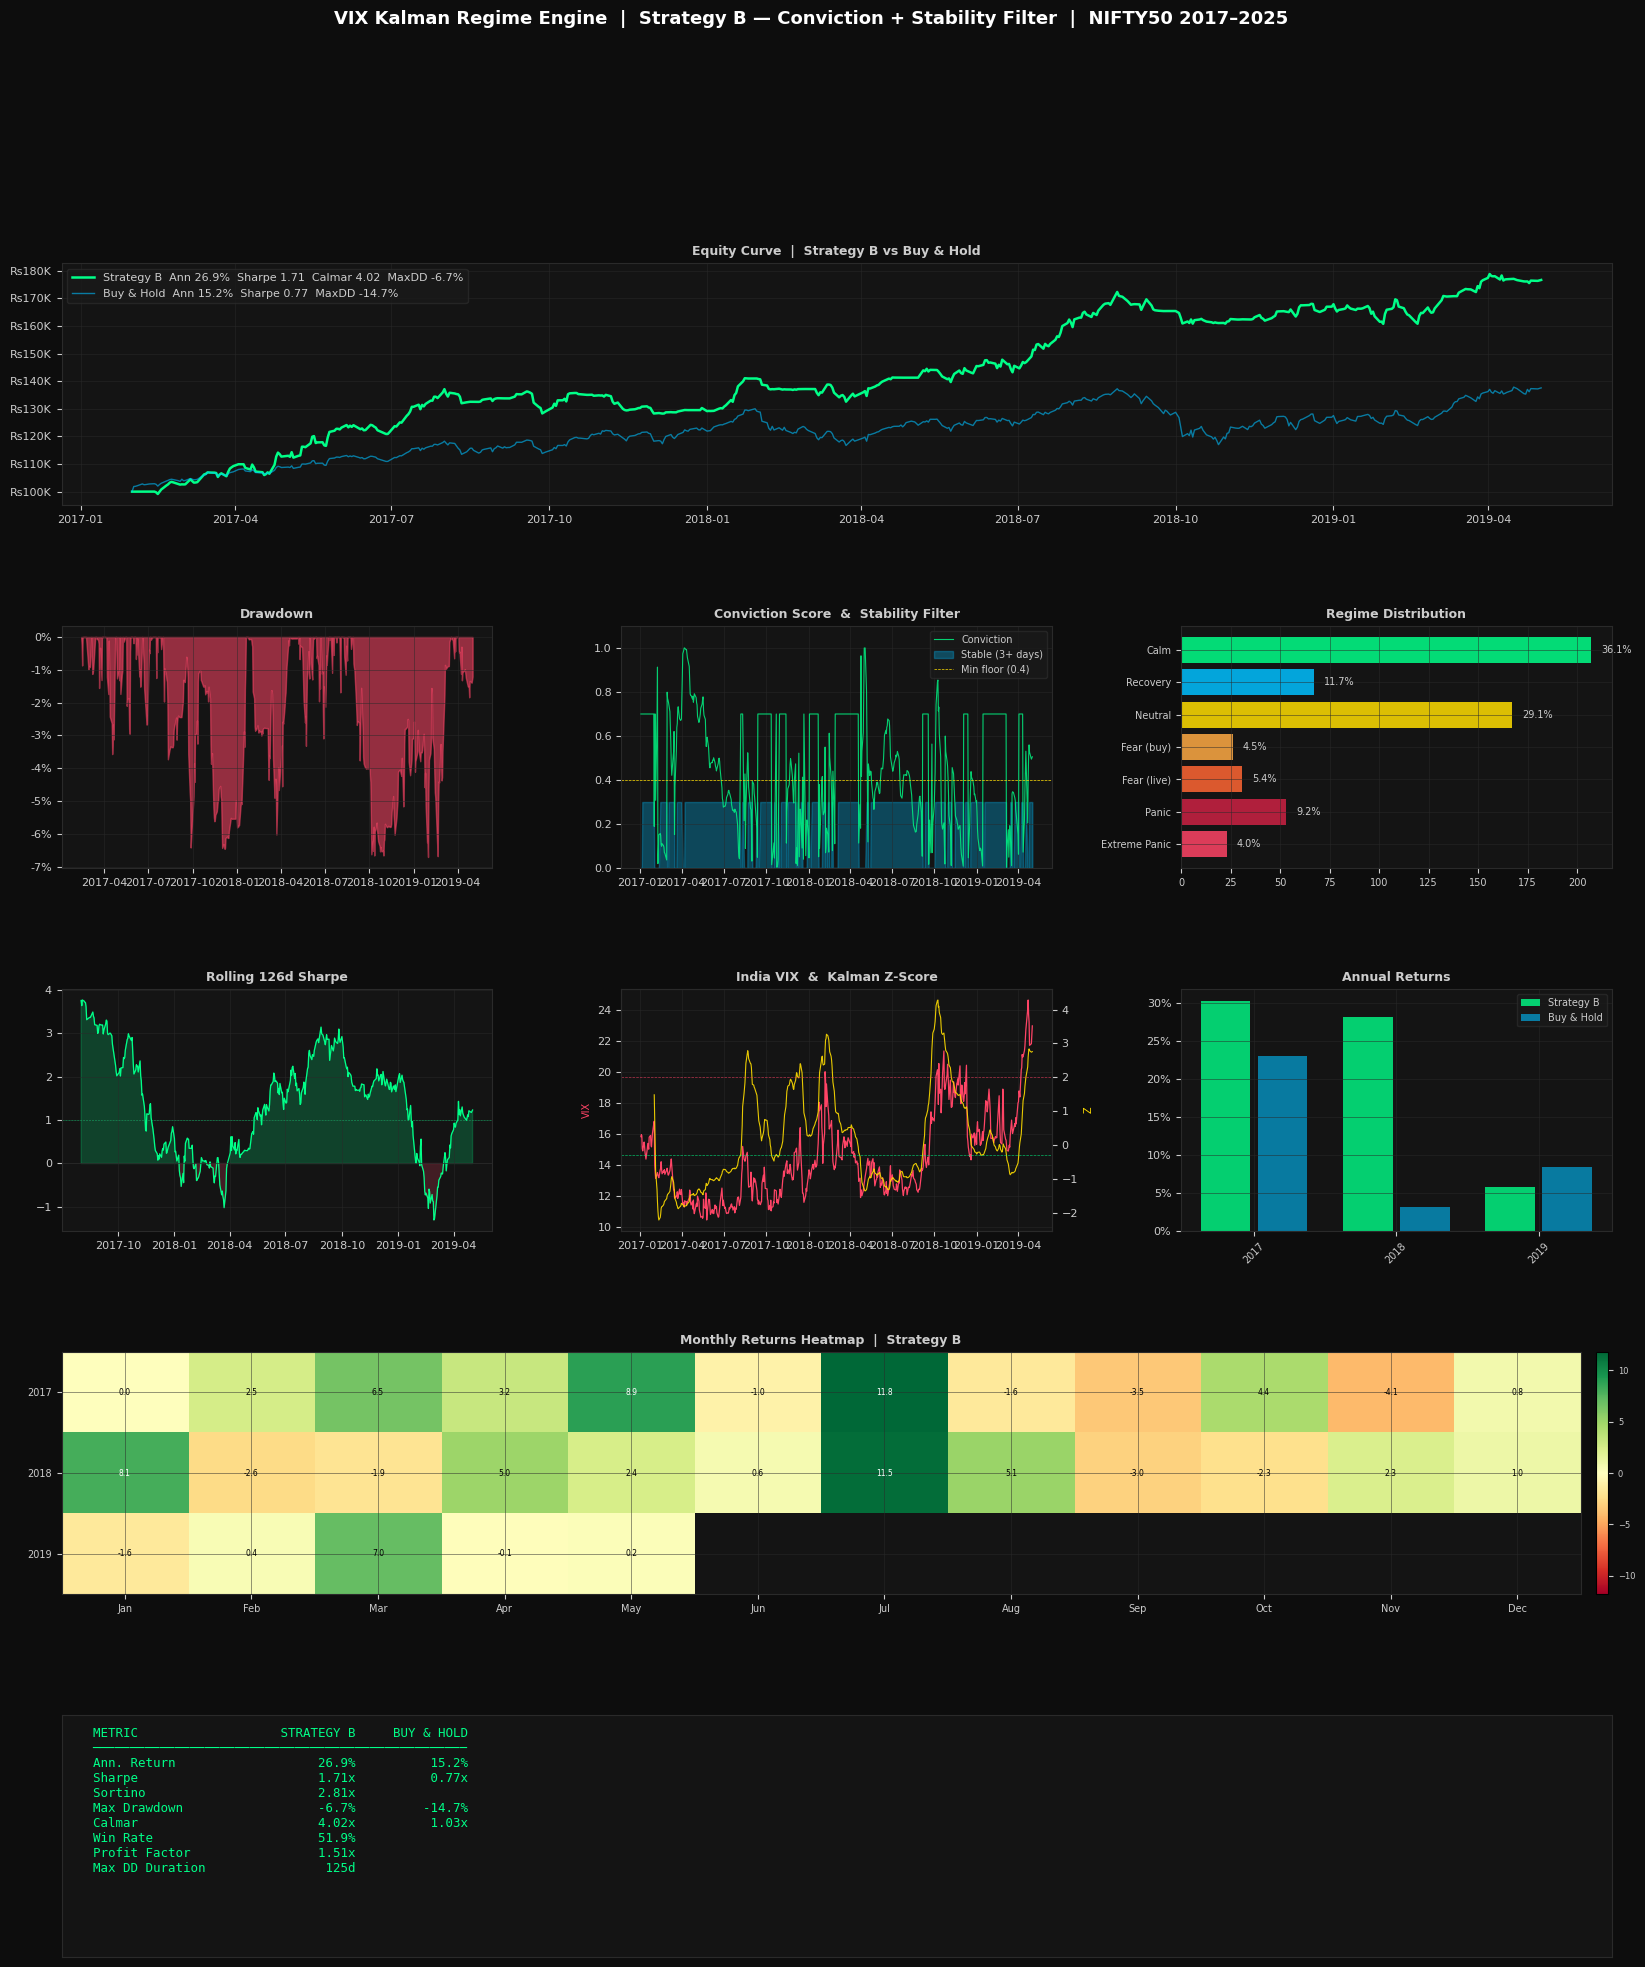

In [9]:
# ── Dashboard ─────────────────────────────────────────────────────────────────
def style(ax, title):
    ax.set_facecolor(C['panel'])
    ax.tick_params(colors=C['text'], labelsize=8)
    ax.set_title(title, color=C['text'], fontsize=9, fontweight='bold', pad=6)
    for sp in ax.spines.values(): sp.set_color(C['grid'])
    ax.grid(True, color=C['grid'], linewidth=0.5, alpha=0.7)

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor(C['bg'])
gs  = gridspec.GridSpec(5, 3, figure=fig, hspace=0.50, wspace=0.30)

ax1 = fig.add_subplot(gs[0, :])
style(ax1, 'Equity Curve  |  Strategy B vs Buy & Hold')
ax1.plot(strat_eq.index, strat_eq, color=C['green'], lw=1.8,
         label=f"Strategy B  Ann {strat_m['ann']*100:.1f}%  Sharpe {strat_m['sharpe']:.2f}  Calmar {strat_m['calmar']:.2f}  MaxDD {strat_m['mdd']*100:.1f}%")
ax1.plot(bench_eq.index, bench_eq, color=C['blue'], lw=1.0, alpha=0.6,
         label=f"Buy & Hold  Ann {bench_m['ann']*100:.1f}%  Sharpe {bench_m['sharpe']:.2f}  MaxDD {bench_m['mdd']*100:.1f}%")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'Rs{x/1000:.0f}K'))
ax1.legend(fontsize=8, facecolor='#1a1a1a', edgecolor=C['grid'], labelcolor=C['text'], loc='upper left')

ax2 = fig.add_subplot(gs[1, 0])
style(ax2, 'Drawdown')
ax2.fill_between(strat_dd.index, strat_dd*100, 0, color=C['red'], alpha=0.55)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))

ax3 = fig.add_subplot(gs[1, 1])
style(ax3, 'Conviction Score  &  Stability Filter')
ax3.plot(vix.index, vix['Conviction'], color=C['green'], lw=0.8, alpha=0.8, label='Conviction')
ax3.fill_between(vix.index, vix['IsStable']*0.3, 0, color=C['blue'], alpha=0.3, label='Stable (3+ days)')
ax3.axhline(0.4, color=C['gold'], lw=0.5, ls='--', label='Min floor (0.4)')
ax3.set_ylim(0, 1.1)
ax3.legend(fontsize=7, facecolor='#1a1a1a', edgecolor=C['grid'], labelcolor=C['text'])

ax4 = fig.add_subplot(gs[1, 2])
style(ax4, 'Regime Distribution')
order  = ['Extreme Panic','Panic','Fear (live)','Fear (buy)','Neutral','Recovery','Calm']
cols   = [C['red'],'#cc2244','#ff6633','#ffaa44',C['gold'],C['blue'],C['green']]
counts = [(regime == r).sum() for r in order]
bars   = ax4.barh(order, counts, color=cols, alpha=0.85)
total  = sum(counts)
for bar, cnt in zip(bars, counts):
    ax4.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
             f'{cnt/total*100:.1f}%', va='center', color=C['text'], fontsize=7)
ax4.tick_params(colors=C['text'], labelsize=7)
for sp in ax4.spines.values(): sp.set_color(C['grid'])

ax5 = fig.add_subplot(gs[2, 0])
style(ax5, 'Rolling 126d Sharpe')
rs = (strat_ret.rolling(126).mean()*252 - RISK_FREE_RATE) / (strat_ret.rolling(126).std()*np.sqrt(252))
ax5.plot(rs.index, rs, color=C['green'], lw=0.9)
ax5.axhline(0, color=C['grid'], lw=0.5)
ax5.axhline(1, color=C['green'], lw=0.4, ls='--', alpha=0.6)
ax5.fill_between(rs.index, rs, 0, where=rs>=0, color=C['green'], alpha=0.2)
ax5.fill_between(rs.index, rs, 0, where=rs<0,  color=C['red'],   alpha=0.2)

ax6 = fig.add_subplot(gs[2, 1])
style(ax6, 'India VIX  &  Kalman Z-Score')
ax6b = ax6.twinx()
ax6.plot(vix.index,  vix['VIX'],   color=C['red'],  lw=0.9)
ax6b.plot(vix.index, vix['VIX_Z'], color=C['gold'], lw=0.8, alpha=0.9)
ax6b.axhline(2.0,  color=C['red'],   lw=0.5, ls='--', alpha=0.7)
ax6b.axhline(-0.3, color=C['green'], lw=0.5, ls='--', alpha=0.7)
ax6.set_ylabel('VIX',  color=C['red'],  fontsize=7)
ax6b.set_ylabel('Z',   color=C['gold'], fontsize=7)
ax6b.tick_params(colors=C['text'], labelsize=8)
for sp in ax6b.spines.values(): sp.set_color(C['grid'])

ax7 = fig.add_subplot(gs[2, 2])
style(ax7, 'Annual Returns')
years = ann_s.index.year
x     = np.arange(len(years))
ax7.bar(x-0.2, ann_s.values, 0.35, color=C['green'], alpha=0.8, label='Strategy B')
ax7.bar(x+0.2, ann_b.values, 0.35, color=C['blue'],  alpha=0.6, label='Buy & Hold')
ax7.set_xticks(x); ax7.set_xticklabels(years, color=C['text'], fontsize=7, rotation=45)
ax7.axhline(0, color=C['grid'], lw=0.5)
ax7.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax7.legend(fontsize=7, facecolor='#1a1a1a', edgecolor=C['grid'], labelcolor=C['text'])

ax8 = fig.add_subplot(gs[3, :])
style(ax8, 'Monthly Returns Heatmap  |  Strategy B')
monthly = strat_ret.resample('ME').apply(lambda x: (1+x).prod()-1) * 100
mdf     = monthly.to_frame('ret')
mdf['Year']  = mdf.index.year
mdf['Month'] = mdf.index.month
mdf     = mdf.groupby(['Year','Month'])['ret'].mean().reset_index()
pivot   = mdf.pivot(index='Year', columns='Month', values='ret')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]
vals    = pivot.values[~np.isnan(pivot.values)]
vmax    = max(abs(vals).max(), 1) if len(vals) else 1
im      = ax8.imshow(pivot.values, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
ax8.set_xticks(range(len(pivot.columns))); ax8.set_xticklabels(pivot.columns, color=C['text'], fontsize=7)
ax8.set_yticks(range(len(pivot.index)));   ax8.set_yticklabels(pivot.index,   color=C['text'], fontsize=7)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i,j]
        if not np.isnan(v):
            ax8.text(j, i, f'{v:.1f}', ha='center', va='center',
                     fontsize=5.5, color='black' if abs(v)<vmax*0.6 else 'white')
plt.colorbar(im, ax=ax8, fraction=0.01, pad=0.01).ax.tick_params(colors=C['text'], labelsize=6)

ax9 = fig.add_subplot(gs[4, :])
ax9.set_facecolor(C['panel'])
for sp in ax9.spines.values(): sp.set_color(C['grid'])
ax9.set_xticks([]); ax9.set_yticks([])
txt = (
    f"{'METRIC':<22} {'STRATEGY B':>12}   {'BUY & HOLD':>12}\n"
    f"{'─'*50}\n"
    f"{'Ann. Return':<22} {strat_m['ann']*100:>11.1f}%   {bench_m['ann']*100:>11.1f}%\n"
    f"{'Sharpe':<22} {strat_m['sharpe']:>11.2f}x   {bench_m['sharpe']:>11.2f}x\n"
    f"{'Sortino':<22} {strat_m['sortino']:>11.2f}x\n"
    f"{'Max Drawdown':<22} {strat_m['mdd']*100:>11.1f}%   {bench_m['mdd']*100:>11.1f}%\n"
    f"{'Calmar':<22} {strat_m['calmar']:>11.2f}x   {bench_m['calmar']:>11.2f}x\n"
    f"{'Win Rate':<22} {strat_m['wr']*100:>11.1f}%\n"
    f"{'Profit Factor':<22} {strat_m['pf']:>11.2f}x\n"
    f"{'Max DD Duration':<22} {strat_m['mdd_days']:>11d}d"
)
ax9.text(0.02, 0.95, txt, transform=ax9.transAxes, fontsize=9,
         color=C['green'], fontfamily='monospace', va='top')

fig.suptitle('VIX Kalman Regime Engine  |  Strategy B — Conviction + Stability Filter  |  NIFTY50 2017–2025',
             color='white', fontsize=13, fontweight='bold', y=0.995)
plt.savefig('strategy_b_dashboard.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print('Dashboard saved to strategy_b_dashboard.png')
plt.show()